In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 19.7 MB/s eta 0:00:06
   ---------------------------------------- 0.8/101.7 MB 3.6 MB/s eta 0:00:29
    --------------------------------------- 1.3/101.7 MB 2.7 MB/s eta 0:00:38
    --------------------------------------- 1.8/101.7 MB 2.4 MB/s eta 0:00:41
    --------------------------------------- 2.1/101.7 MB 2.3 MB/s eta 0:00:43
   - -------------------------------------- 2.6/101.7 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 2.9/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 3.4/101.7 MB 2.1 MB/s eta 0:00:47
   - -------------------------------------- 3.7/101.7 MB 2.1 MB/s eta 0:00:47
   - -------------------------------------- 4.2/101.7 MB 2.1 MB/s eta 0:00:48
   - -------------------------------------- 4.7/101.7 MB 2.0 MB/s eta 0:00:48

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [4]:
df = pd.read_csv("synthetic_toxicity_dataset_1000.csv")

X = df.drop("toxicity", axis=1)
y = df["toxicity"]

In [5]:
#Lbael-encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [8]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)


In [9]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [10]:
y_test_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)
print("Accuracy:", accuracy_score(y_test_decoded, y_pred_decoded))
print(classification_report(y_test_decoded, y_pred_decoded))

Accuracy: 0.925
              precision    recall  f1-score   support

        High       0.94      0.97      0.96       153
         Low       1.00      0.33      0.50         3
      Medium       0.85      0.80      0.82        44

    accuracy                           0.93       200
   macro avg       0.93      0.70      0.76       200
weighted avg       0.92      0.93      0.92       200



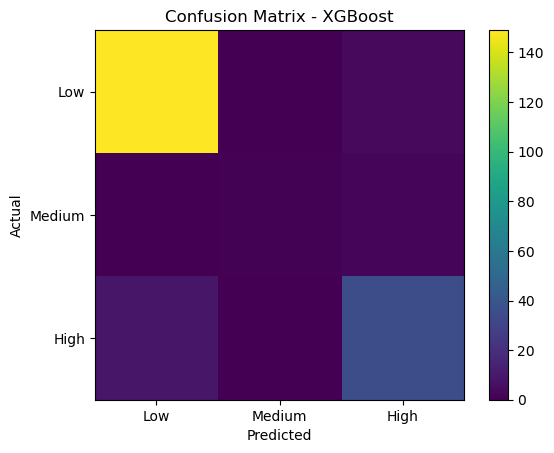

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test_decoded, y_pred_decoded)

plt.imshow(cm)
plt.title("Confusion Matrix - XGBoost")
plt.colorbar()

classes = ["Low", "Medium", "High"]
plt.xticks(np.arange(3), classes)
plt.yticks(np.arange(3), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

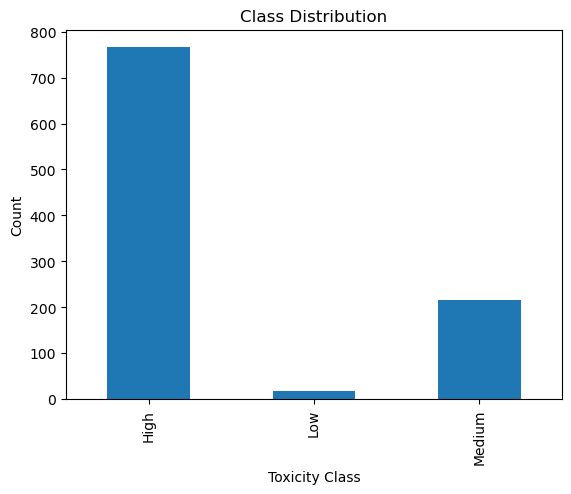

In [12]:
import matplotlib.pyplot as plt
counts = df["toxicity"].value_counts().sort_index()
counts.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Toxicity Class")
plt.ylabel("Count")
plt.show()